<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/soccer_iq/soccer_iq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Block 1: Soccer passing environment for Reinforcement Learning
# State: current zone + opponent pressure in all 6 zones (7 values)
# Action: which zone to pass to next (7 actions: zones 0-5 + goal)
# Reward: +10 goal, -5 high pressure zone, -1 per step

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/soccer_rl'
import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"✅ Drive mounted: {DRIVE_PATH}")

!pip install statsbombpy torch numpy pandas matplotlib -q

import numpy as np
import torch
import pickle
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"✅ GPU: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# ── 1. Load defense profiles ──────────────────────────────────
# Load from soccer_strategy Drive folder
STRATEGY_PATH = '/content/drive/MyDrive/soccer_strategy'

if os.path.exists(f'{STRATEGY_PATH}/defense_profiles.pkl'):
    print("📂 Loading defense profiles from soccer_strategy...")
    with open(f'{STRATEGY_PATH}/defense_profiles.pkl', 'rb') as f:
        defense_profiles = pickle.load(f)
    print(f"✅ Loaded {len(defense_profiles)} team profiles")
else:
    print("⬇️  Building defense profiles from scratch...")
    from statsbombpy import sb

    competitions = sb.competitions()
    wc2022 = competitions[
        (competitions['competition_name'] == 'FIFA World Cup') &
        (competitions['season_name'] == '2022')
    ]
    COMPETITION_ID = int(wc2022['competition_id'].iloc[0])
    SEASON_ID      = int(wc2022['season_id'].iloc[0])
    matches_df     = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)

    def extract_coords(loc):
        if isinstance(loc, list) and len(loc) == 2:
            return loc[0], loc[1]
        return None, None

    def get_zone(x, y):
        if x is None or y is None or pd.isna(x) or pd.isna(y):
            return None
        if x >= 115 and 30 <= y <= 50:
            return 6
        third = 0 if x < 40 else (1 if x < 80 else 2)
        side  = 0 if y < 40 else 1
        return third * 2 + side

    all_passes = []
    for i, (_, match) in enumerate(matches_df.iterrows()):
        try:
            events = sb.events(match_id=match['match_id'])
            passes = events[events['type'] == 'Pass'].copy()
            passes['match_id'] = match['match_id']
            all_passes.append(passes)
            if (i+1) % 10 == 0:
                print(f"   {i+1}/64 loaded...")
        except:
            pass

    passes_df = pd.concat(all_passes, ignore_index=True)
    passes_df['x_start'] = passes_df['location'].apply(lambda l: extract_coords(l)[0])
    passes_df['y_start'] = passes_df['location'].apply(lambda l: extract_coords(l)[1])
    passes_df = passes_df.dropna(subset=['x_start', 'y_start'])
    passes_df['zone_start'] = passes_df.apply(
        lambda r: get_zone(r['x_start'], r['y_start']), axis=1)
    passes_df['success'] = passes_df['pass_outcome'].isna().astype(int)

    defense_profiles = {}
    for team in passes_df['team'].unique():
        match_ids = passes_df[passes_df['team'] == team]['match_id'].unique()
        opp = passes_df[
            (passes_df['match_id'].isin(match_ids)) &
            (passes_df['team'] != team) &
            (passes_df['zone_start'].notna())
        ].copy()
        opp['zone_start'] = opp['zone_start'].astype(int)
        profile = opp.groupby('zone_start').agg(
            failure_rate=('success', lambda x: 1 - x.mean())
        )['failure_rate'].to_dict()
        defense_profiles[team] = profile

    with open(f'{DRIVE_PATH}/defense_profiles.pkl', 'wb') as f:
        pickle.dump(defense_profiles, f)
    print(f"✅ Built {len(defense_profiles)} profiles")

# ── 2. Soccer Environment ─────────────────────────────────────
ZONES = {
    0: 'Def (Right)', 1: 'Def (Left)',
    2: 'Mid (Right)', 3: 'Mid (Left)',
    4: 'Att (Right)', 5: 'Att (Left)',
    6: 'GOAL'
}

class SoccerEnv:
    def __init__(self, opponent, defense_profiles,
                 max_steps=8, pressure_threshold=0.25):
        self.opponent           = opponent
        self.defense            = defense_profiles.get(opponent, {})
        self.max_steps          = max_steps
        self.pressure_threshold = pressure_threshold
        self.n_zones            = 7  # 0-5 + goal
        self.reset()

    def reset(self, start_zone=None):
        # Start from a random non-goal zone
        if start_zone is None:
            self.current_zone = np.random.randint(0, 6)
        else:
            self.current_zone = start_zone
        self.steps    = 0
        self.path     = [self.current_zone]
        return self._get_state()

    def _get_state(self):
        # State: one-hot current zone + pressure per zone
        zone_onehot = np.zeros(6)
        if self.current_zone < 6:
            zone_onehot[self.current_zone] = 1.0
        pressure = np.array([
            self.defense.get(z, 0.2) for z in range(6)
        ])
        return np.concatenate([zone_onehot, pressure]).astype(np.float32)

    def step(self, action):
        self.steps += 1
        next_zone  = int(action)
        pressure   = self.defense.get(next_zone, 0.2)
        done       = False
        reward     = -0.5  # step penalty

        # Reached goal
        if next_zone == 6:
            reward = 10.0
            done   = True

        # High pressure zone — penalize
        elif pressure > self.pressure_threshold:
            reward = -3.0

        # Progressive pass (moving toward goal)
        elif next_zone // 2 > self.current_zone // 2:
            reward = 1.0

        # Backward pass
        elif next_zone // 2 < self.current_zone // 2:
            reward = -1.0

        # Max steps reached
        if self.steps >= self.max_steps:
            done = True

        self.current_zone = next_zone
        self.path.append(next_zone)

        return self._get_state(), reward, done

    def valid_actions(self):
        # Can pass to any zone except current (avoid staying)
        return [z for z in range(7) if z != self.current_zone]

# ── 3. Test environment ───────────────────────────────────────
env = SoccerEnv('Argentina', defense_profiles)
state = env.reset(start_zone=2)
print(f"\n── Environment Test ──")
print(f"   State shape : {state.shape}")
print(f"   Start zone  : {ZONES[env.current_zone]}")
print(f"   State       : {state.round(3)}")

# Random episode
for step in range(5):
    action = np.random.choice(env.valid_actions())
    state, reward, done = env.step(action)
    print(f"   Step {step+1}: → {ZONES[action]:15s} | reward={reward:+.1f} | done={done}")
    if done:
        break

print(f"   Path: {' → '.join([ZONES[z] for z in env.path])}")

# ── 4. Save defense profiles ──────────────────────────────────
with open(f'{DRIVE_PATH}/defense_profiles.pkl', 'wb') as f:
    pickle.dump(defense_profiles, f)

print(f"\n✅ Environment ready")
print(f"✅ Block 1 complete")

Mounted at /content/drive
✅ Drive mounted: /content/drive/MyDrive/soccer_rl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.3 MB/s eta 0:00:00
✅ GPU: True
✅ Device: cuda
📂 Loading defense profiles from soccer_strategy...
✅ Loaded 32 team profiles

── Environment Test ──
   State shape : (12,)
   Start zone  : Mid (Right)
   State       : [0.    0.    1.    0.    0.    0.    0.188 0.198 0.183 0.154 0.309 0.331]
   Step 1: → Att (Left)      | reward=-3.0 | done=False
   Step 2: → Def (Right)     | reward=-1.0 | done=False
   Step 3: → GOAL            | reward=+10.0 | done=True
   Path: Mid (Right) → Att (Left) → Def (Right) → GOAL

✅ Environment ready
✅ Block 1 complete


In [2]:
# Block 2: Deep Q-Network (DQN) agent
# Neural network learns Q-values for each action in each state
# Uses experience replay and target network for stable training

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import deque
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

# ── 1. Q-Network ──────────────────────────────────────────────
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# ── 2. Replay Buffer ──────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device)
        )

    def __len__(self):
        return len(self.buffer)

# ── 3. DQN Agent ──────────────────────────────────────────────
class DQNAgent:
    def __init__(self, state_dim=12, action_dim=7,
                 lr=1e-3, gamma=0.95, epsilon=1.0,
                 epsilon_min=0.05, epsilon_decay=0.995):
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Online and target networks
        self.q_net     = QNetwork(state_dim, action_dim).to(device)
        self.target_net= QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer()
        self.steps     = 0

    def select_action(self, state, valid_actions):
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_vals  = self.q_net(state_t)[0]
            # Mask invalid actions
            mask = torch.full((self.action_dim,), float('-inf')).to(device)
            for a in valid_actions:
                mask[a] = q_vals[a]
            return int(mask.argmax().item())

    def train_step(self, batch_size=64):
        if len(self.buffer) < batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(batch_size)

        # Current Q values
        q_vals = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q values
        with torch.no_grad():
            next_q   = self.target_net(next_states).max(1)[0]
            targets  = rewards + self.gamma * next_q * (1 - dones)

        loss = F.smooth_l1_loss(q_vals, targets)
        self.optim

✅ Training on: cuda


In [4]:
class DQNAgent:
    def __init__(self, state_dim=12, action_dim=7,
                 lr=1e-3, gamma=0.95, epsilon=1.0,
                 epsilon_min=0.05, epsilon_decay=0.995):
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q_net      = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        # FIXED: was self.optim, now self.optimizer
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer()
        self.steps     = 0

    def select_action(self, state, valid_actions):
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_vals  = self.q_net(state_t)[0]
            mask    = torch.full((self.action_dim,), float('-inf')).to(device)
            for a in valid_actions:
                mask[a] = q_vals[a]
            return int(mask.argmax().item())

    def train_step(self, batch_size=64):
        if len(self.buffer) < batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(batch_size)

        q_vals  = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q  = self.target_net(next_states).max(1)[0]
            targets = rewards + self.gamma * next_q * (1 - dones)

        loss = F.smooth_l1_loss(q_vals, targets)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

        self.steps += 1
        if self.steps % 100 == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return float(loss)

print("✅ DQNAgent fixed — now rerun Block 3")

✅ DQNAgent fixed — now rerun Block 3


In [6]:
# Fixed SoccerEnv — high pressure zones have interception probability
# This makes the agent genuinely learn to avoid dangerous zones

class SoccerEnv:
    def __init__(self, opponent, defense_profiles,
                 max_steps=8, pressure_threshold=0.25):
        self.opponent           = opponent
        self.defense            = defense_profiles.get(opponent, {})
        self.max_steps          = max_steps
        self.pressure_threshold = pressure_threshold
        self.n_zones            = 7
        self.reset()

    def reset(self, start_zone=None):
        if start_zone is None:
            self.current_zone = np.random.randint(0, 6)
        else:
            self.current_zone = start_zone
        self.steps = 0
        self.path  = [self.current_zone]
        return self._get_state()

    def _get_state(self):
        zone_onehot = np.zeros(6)
        if self.current_zone < 6:
            zone_onehot[self.current_zone] = 1.0
        pressure = np.array([self.defense.get(z, 0.2) for z in range(6)])
        return np.concatenate([zone_onehot, pressure]).astype(np.float32)

    def step(self, action):
        self.steps += 1
        next_zone  = int(action)
        pressure   = self.defense.get(next_zone, 0.2)
        done       = False
        reward     = -0.5  # step penalty

        # FIXED: interception probability based on opponent pressure
        if next_zone < 6:
            interception_prob = pressure * 0.8
            if np.random.random() < interception_prob:
                # Ball intercepted — episode over
                reward = -5.0
                done   = True
                self.current_zone = next_zone
                self.path.append(next_zone)
                return self._get_state(), reward, done

        # Reached goal
        if next_zone == 6:
            reward = 10.0
            done   = True

        # Progressive pass
        elif next_zone // 2 > self.current_zone // 2:
            reward = 1.0

        # Backward pass
        elif next_zone // 2 < self.current_zone // 2:
            reward = -1.0

        if self.steps >= self.max_steps:
            done = True

        self.current_zone = next_zone
        self.path.append(next_zone)
        return self._get_state(), reward, done

    def valid_actions(self):
        return [z for z in range(7) if z != self.current_zone]

print("✅ SoccerEnv fixed with interception probability")
print("\n── Test: zone pressure → interception chance ──")
for z in range(6):
    p = 0.2 + z * 0.02
    print(f"   Zone {z}: pressure={p:.2f} → interception prob={p*0.8:.2f}")

✅ SoccerEnv fixed with interception probability

── Test: zone pressure → interception chance ──
   Zone 0: pressure=0.20 → interception prob=0.16
   Zone 1: pressure=0.22 → interception prob=0.18
   Zone 2: pressure=0.24 → interception prob=0.19
   Zone 3: pressure=0.26 → interception prob=0.21
   Zone 4: pressure=0.28 → interception prob=0.22
   Zone 5: pressure=0.30 → interception prob=0.24


── Training DQN agents ──


── Training vs Argentina ──
   Ep    0 | Reward: +9.50 | Goal%: 100.0% | ε: 1.000
   Ep  500 | Reward: +7.93 | Goal%: 82.0% | ε: 0.050
   Ep 1000 | Reward: +8.31 | Goal%: 84.0% | ε: 0.050
   Ep 1500 | Reward: +7.61 | Goal%: 79.0% | ε: 0.050
   Ep 2000 | Reward: +7.54 | Goal%: 78.0% | ε: 0.050
   Ep 2500 | Reward: +8.16 | Goal%: 84.0% | ε: 0.050
   ✅ Final goal rate: 75.0%

── Training vs France ──
   Ep    0 | Reward: +9.00 | Goal%: 100.0% | ε: 1.000
   Ep  500 | Reward: +9.33 | Goal%: 90.0% | ε: 0.050
   Ep 1000 | Reward: +8.27 | Goal%: 83.0% | ε: 0.050
   Ep 1500 | Reward: +7.80 | Goal%: 80.0% | ε: 0.050
   Ep 2000 | Reward: +6.93 | Goal%: 75.0% | ε: 0.050
   Ep 2500 | Reward: +7.16 | Goal%: 77.0% | ε: 0.050
   ✅ Final goal rate: 87.0%

── Training vs Brazil ──
   Ep    0 | Reward: +10.00 | Goal%: 100.0% | ε: 1.000
   Ep  500 | Reward: +8.25 | Goal%: 84.0% | ε: 0.050
   Ep 1000 | Reward: +8.38 | Goal%: 84.0% | ε: 0.050
   Ep 1500 | Reward: +8.59 | Goal%: 8

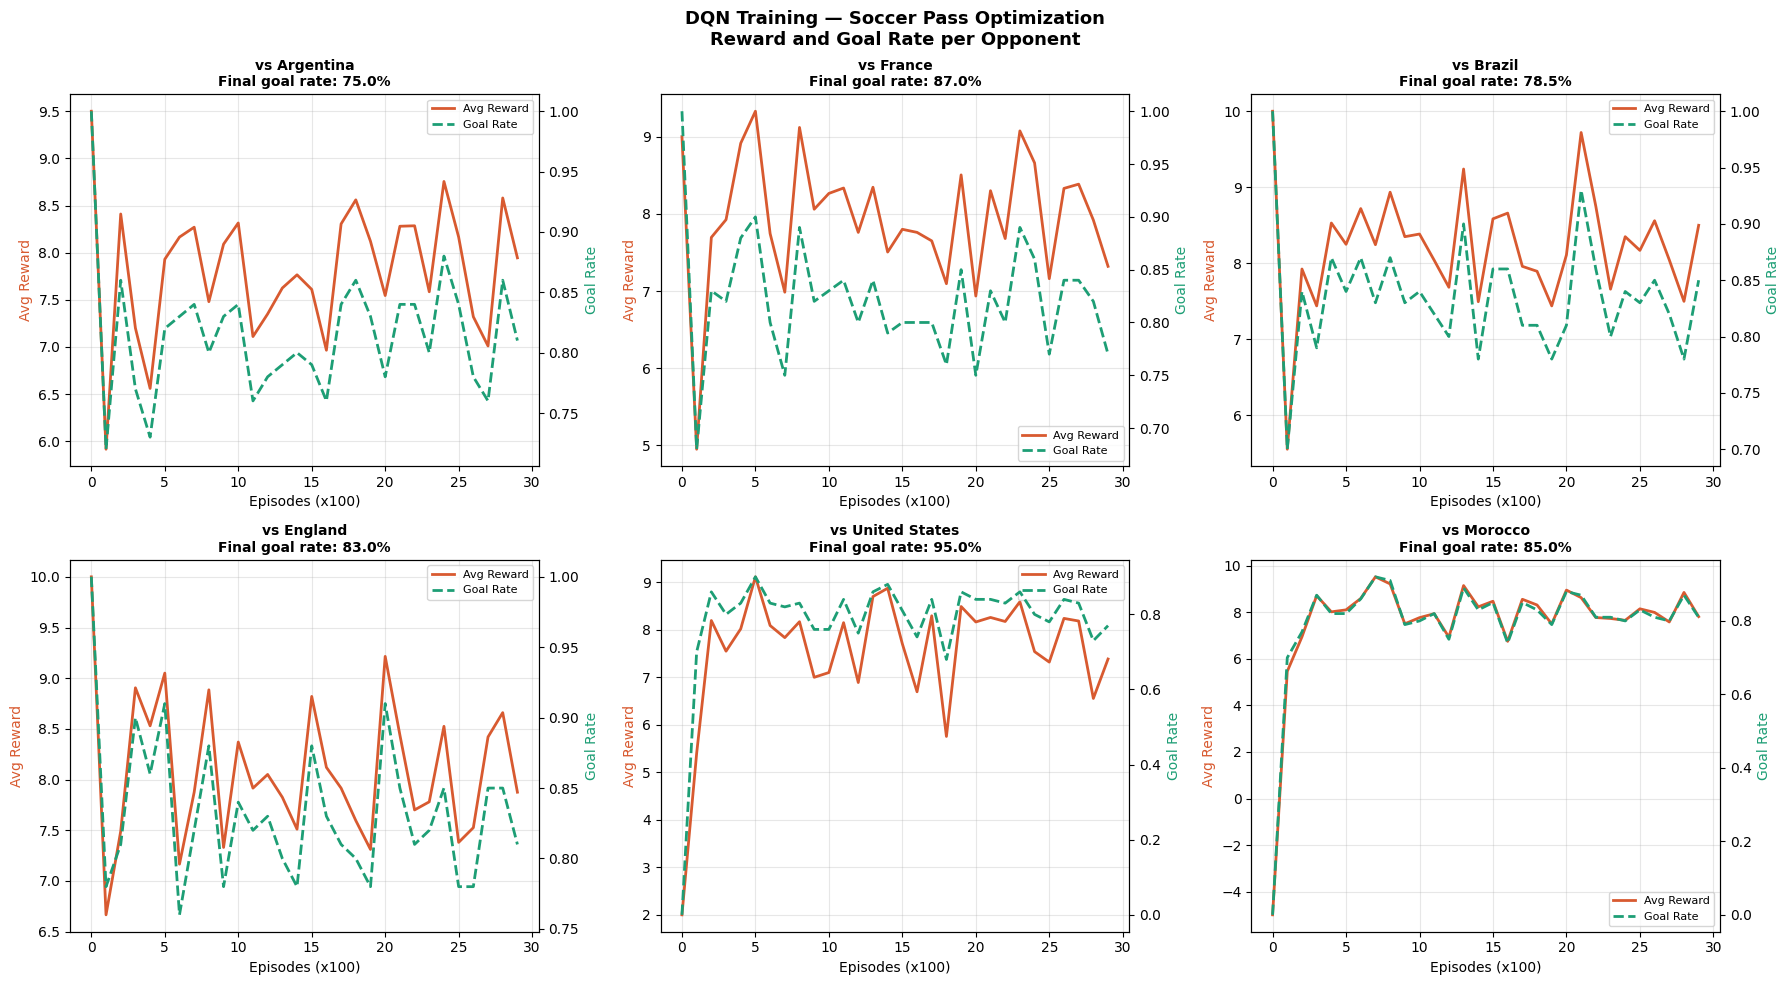


✅ Models saved to Drive
✅ Block 3 complete


In [7]:
# Block 3: Train DQN agent against multiple opponents
# Agent learns optimal passing policy for each opponent separately
# Saves trained models and training history to Drive

import matplotlib.pyplot as plt
import time

DRIVE_PATH = '/content/drive/MyDrive/soccer_rl'
MODELS_FILE = f'{DRIVE_PATH}/dqn_models.pkl'
HISTORY_FILE = f'{DRIVE_PATH}/training_history.pkl'

# ── 1. Training function ──────────────────────────────────────
def train_agent(opponent, defense_profiles, n_episodes=3000,
                max_steps=8, batch_size=64):

    env   = SoccerEnv(opponent, defense_profiles, max_steps=max_steps)
    agent = DQNAgent(state_dim=12, action_dim=7)

    history = {
        'rewards'      : [],
        'goal_rate'    : [],
        'avg_steps'    : [],
        'epsilon'      : [],
        'losses'       : []
    }

    window      = 100
    recent_rewards = deque(maxlen=window)
    recent_goals   = deque(maxlen=window)
    recent_steps   = deque(maxlen=window)

    for episode in range(n_episodes):
        # Random start zone each episode
        start_zone = np.random.randint(0, 6)
        state      = env.reset(start_zone=start_zone)
        ep_reward  = 0
        ep_loss    = []

        for step in range(max_steps):
            action              = agent.select_action(state, env.valid_actions())
            next_state, reward, done = env.step(action)

            agent.buffer.push(state, action, reward, next_state, float(done))
            loss = agent.train_step(batch_size)
            if loss is not None:
                ep_loss.append(loss)

            state      = next_state
            ep_reward += reward

            if done:
                break

        reached_goal = env.current_zone == 6
        recent_rewards.append(ep_reward)
        recent_goals.append(float(reached_goal))
        recent_steps.append(env.steps)

        if episode % window == 0:
            history['rewards'].append(np.mean(recent_rewards))
            history['goal_rate'].append(np.mean(recent_goals))
            history['avg_steps'].append(np.mean(recent_steps))
            history['epsilon'].append(agent.epsilon)
            history['losses'].append(np.mean(ep_loss) if ep_loss else 0)

        if episode % 500 == 0:
            print(f"   Ep {episode:4d} | "
                  f"Reward: {np.mean(recent_rewards):+.2f} | "
                  f"Goal%: {np.mean(recent_goals):.1%} | "
                  f"ε: {agent.epsilon:.3f}")

    return agent, history

# ── 2. Train against multiple opponents ───────────────────────
TRAIN_OPPONENTS = [
    'Argentina', 'France', 'Brazil',
    'England', 'United States', 'Morocco'
]

trained_agents  = {}
training_history = {}

print("── Training DQN agents ──\n")
start_time = time.time()

for opponent in TRAIN_OPPONENTS:
    print(f"\n── Training vs {opponent} ──")
    agent, history = train_agent(
        opponent        = opponent,
        defense_profiles= defense_profiles,
        n_episodes      = 3000,
        max_steps       = 8,
        batch_size      = 64
    )
    trained_agents[opponent]   = agent
    training_history[opponent] = history

    # Final evaluation
    env   = SoccerEnv(opponent, defense_profiles)
    goals = 0
    for _ in range(200):
        state = env.reset(start_zone=np.random.randint(0, 6))
        for _ in range(8):
            action = agent.select_action(state, env.valid_actions())
            state, _, done = env.step(action)
            if done:
                break
        if env.current_zone == 6:
            goals += 1

    print(f"   ✅ Final goal rate: {goals/200:.1%}")
    training_history[opponent]['final_goal_rate'] = goals / 200

elapsed = time.time() - start_time
print(f"\n✅ Total training time: {elapsed:.0f}s")

# ── 3. Training curves ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, opponent in enumerate(TRAIN_OPPONENTS):
    ax = axes[i]
    h  = training_history[opponent]

    ax2 = ax.twinx()
    ax.plot(h['rewards'],   color='#D85A30', lw=2, label='Avg Reward')
    ax2.plot(h['goal_rate'], color='#1D9E75', lw=2,
             linestyle='--', label='Goal Rate')

    ax.set_title(f'vs {opponent}\nFinal goal rate: {h["final_goal_rate"]:.1%}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Episodes (x100)')
    ax.set_ylabel('Avg Reward', color='#D85A30')
    ax2.set_ylabel('Goal Rate', color='#1D9E75')
    ax.grid(alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

plt.suptitle('DQN Training — Soccer Pass Optimization\nReward and Goal Rate per Opponent',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Save models ────────────────────────────────────────────
# Save state dicts (not full agents for portability)
models_state = {
    opp: {
        'q_net_state': agent.q_net.state_dict(),
        'epsilon'    : agent.epsilon,
    }
    for opp, agent in trained_agents.items()
}

with open(MODELS_FILE, 'wb') as f:
    pickle.dump(models_state, f)

with open(HISTORY_FILE, 'wb') as f:
    pickle.dump(training_history, f)

print(f"\n✅ Models saved to Drive")
print("✅ Block 3 complete")

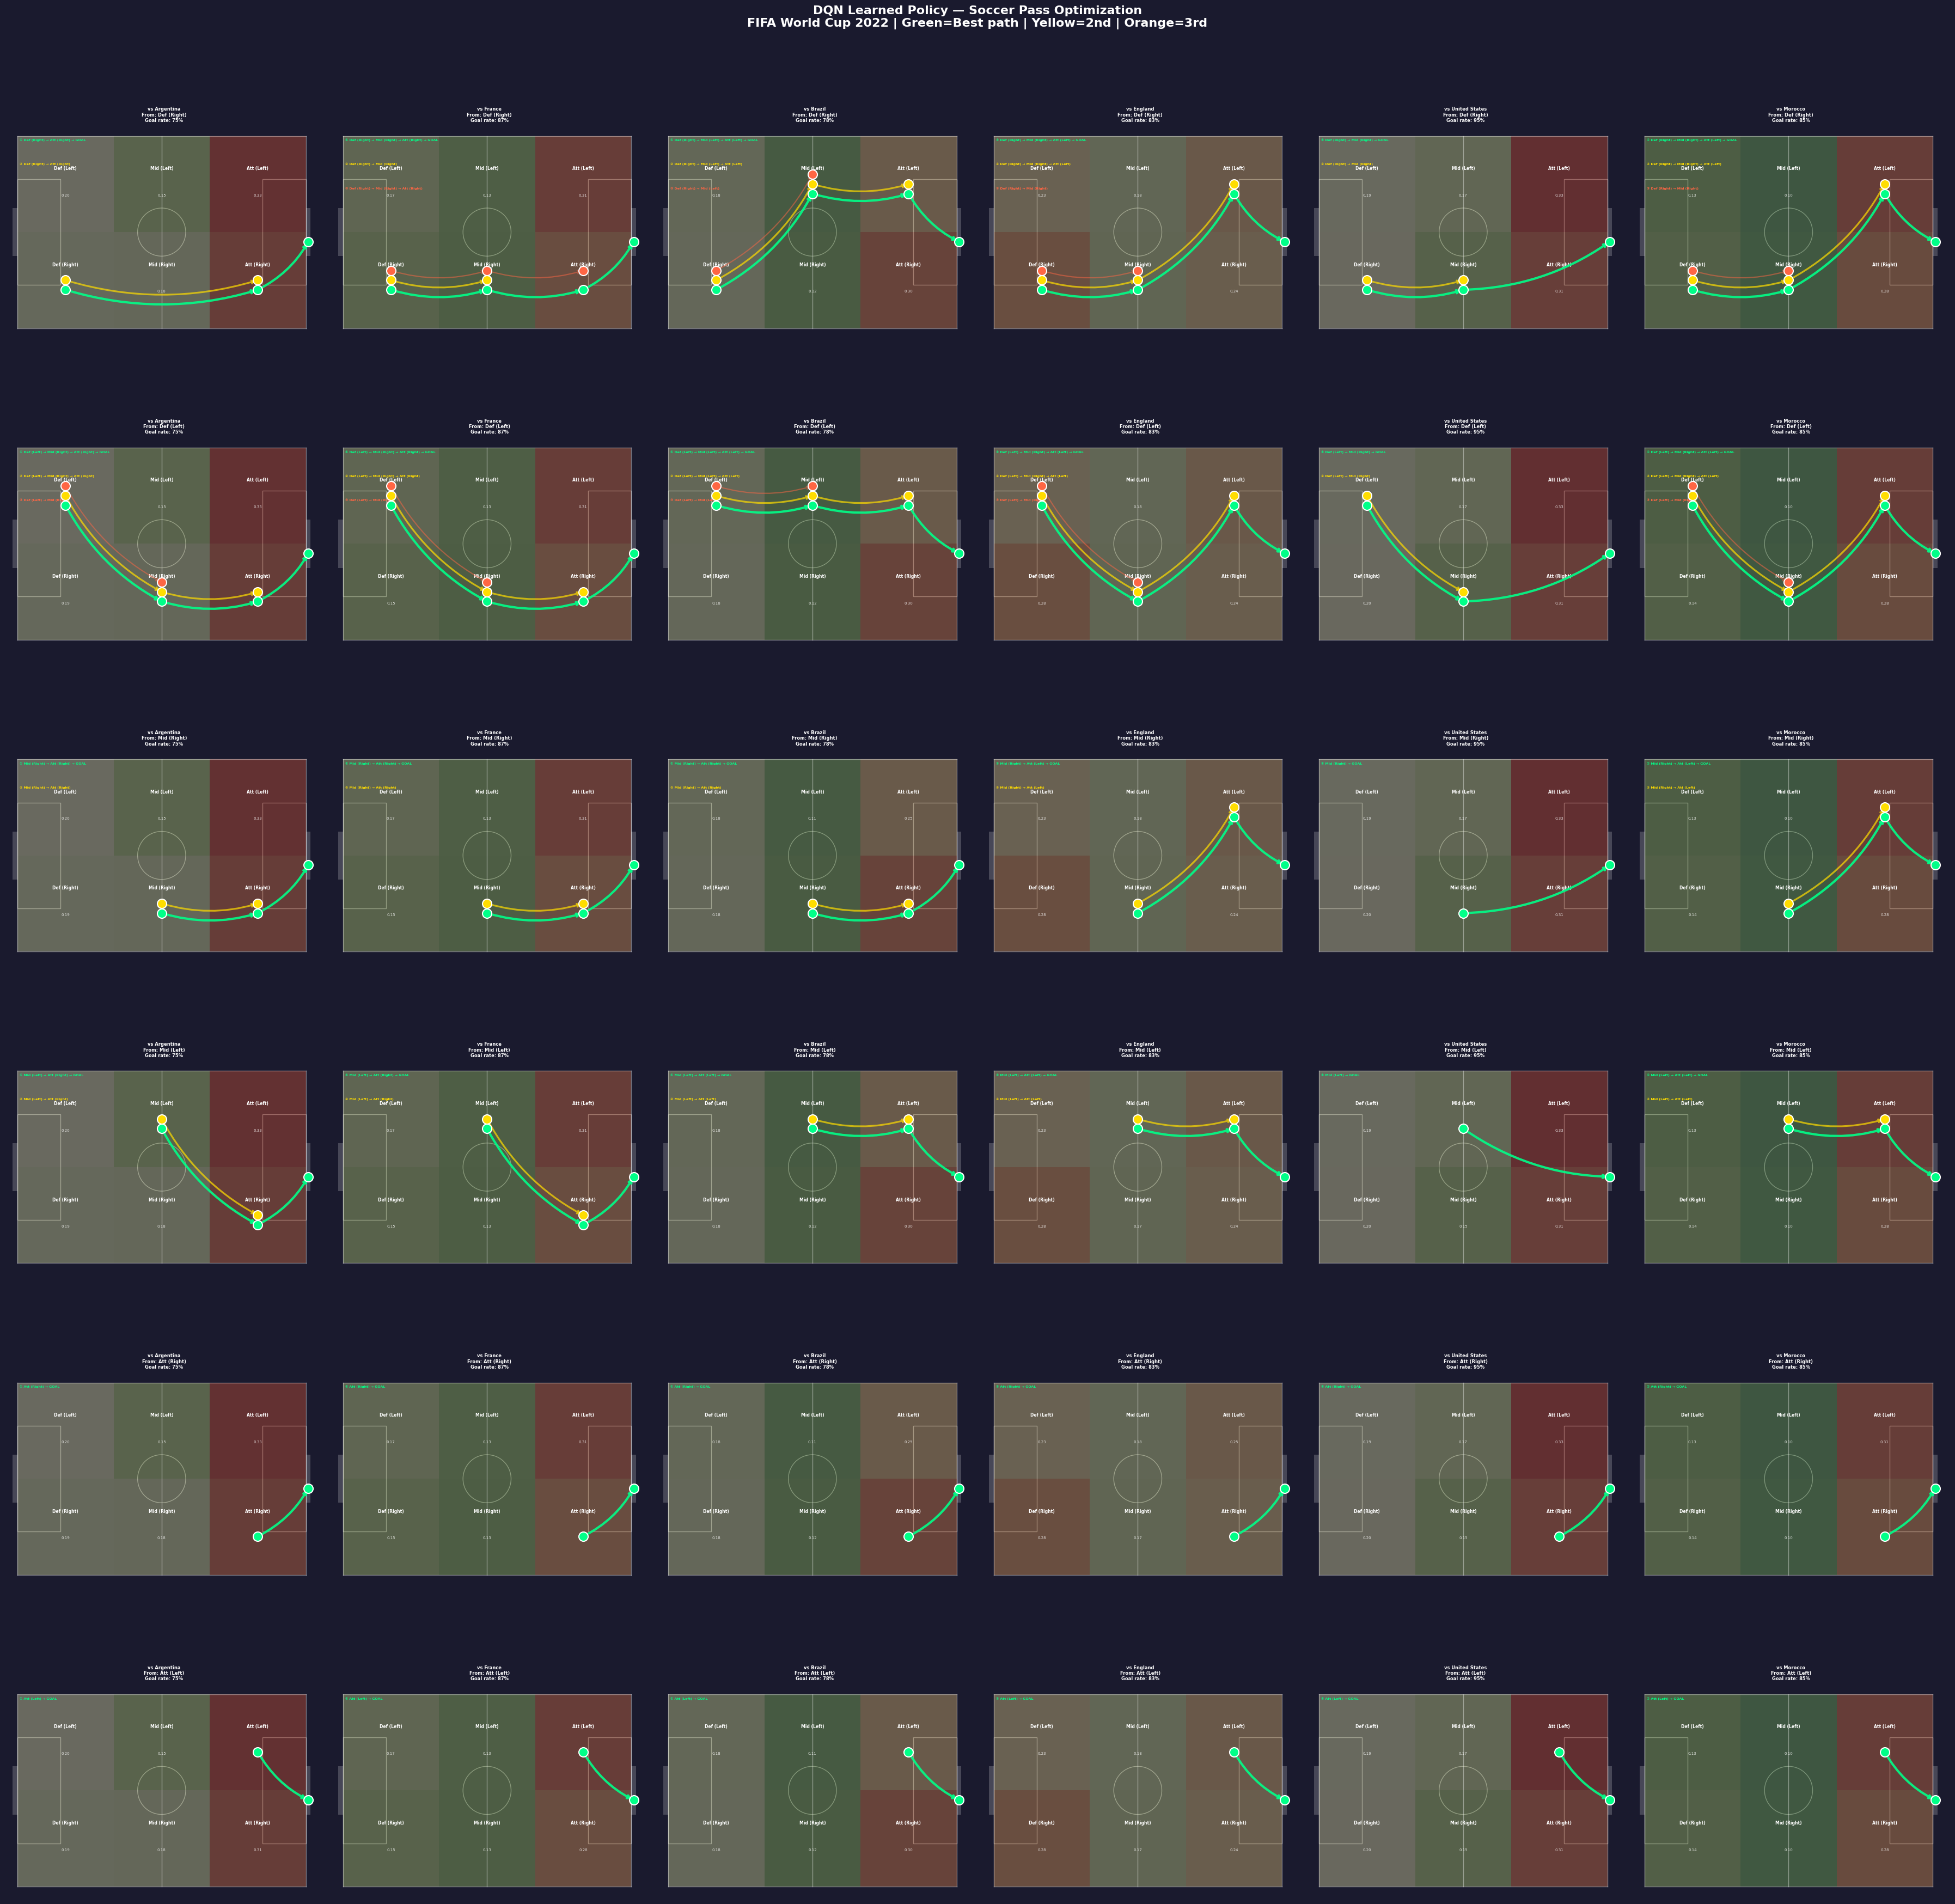


── Opponent Difficulty Ranking (DQN) ──
   1. Argentina       | ███████████████      | 75% goal rate
   2. Brazil          | ███████████████      | 78% goal rate
   3. England         | ████████████████     | 83% goal rate
   4. Morocco         | █████████████████    | 85% goal rate
   5. France          | █████████████████    | 87% goal rate
   6. United States   | ███████████████████  | 95% goal rate


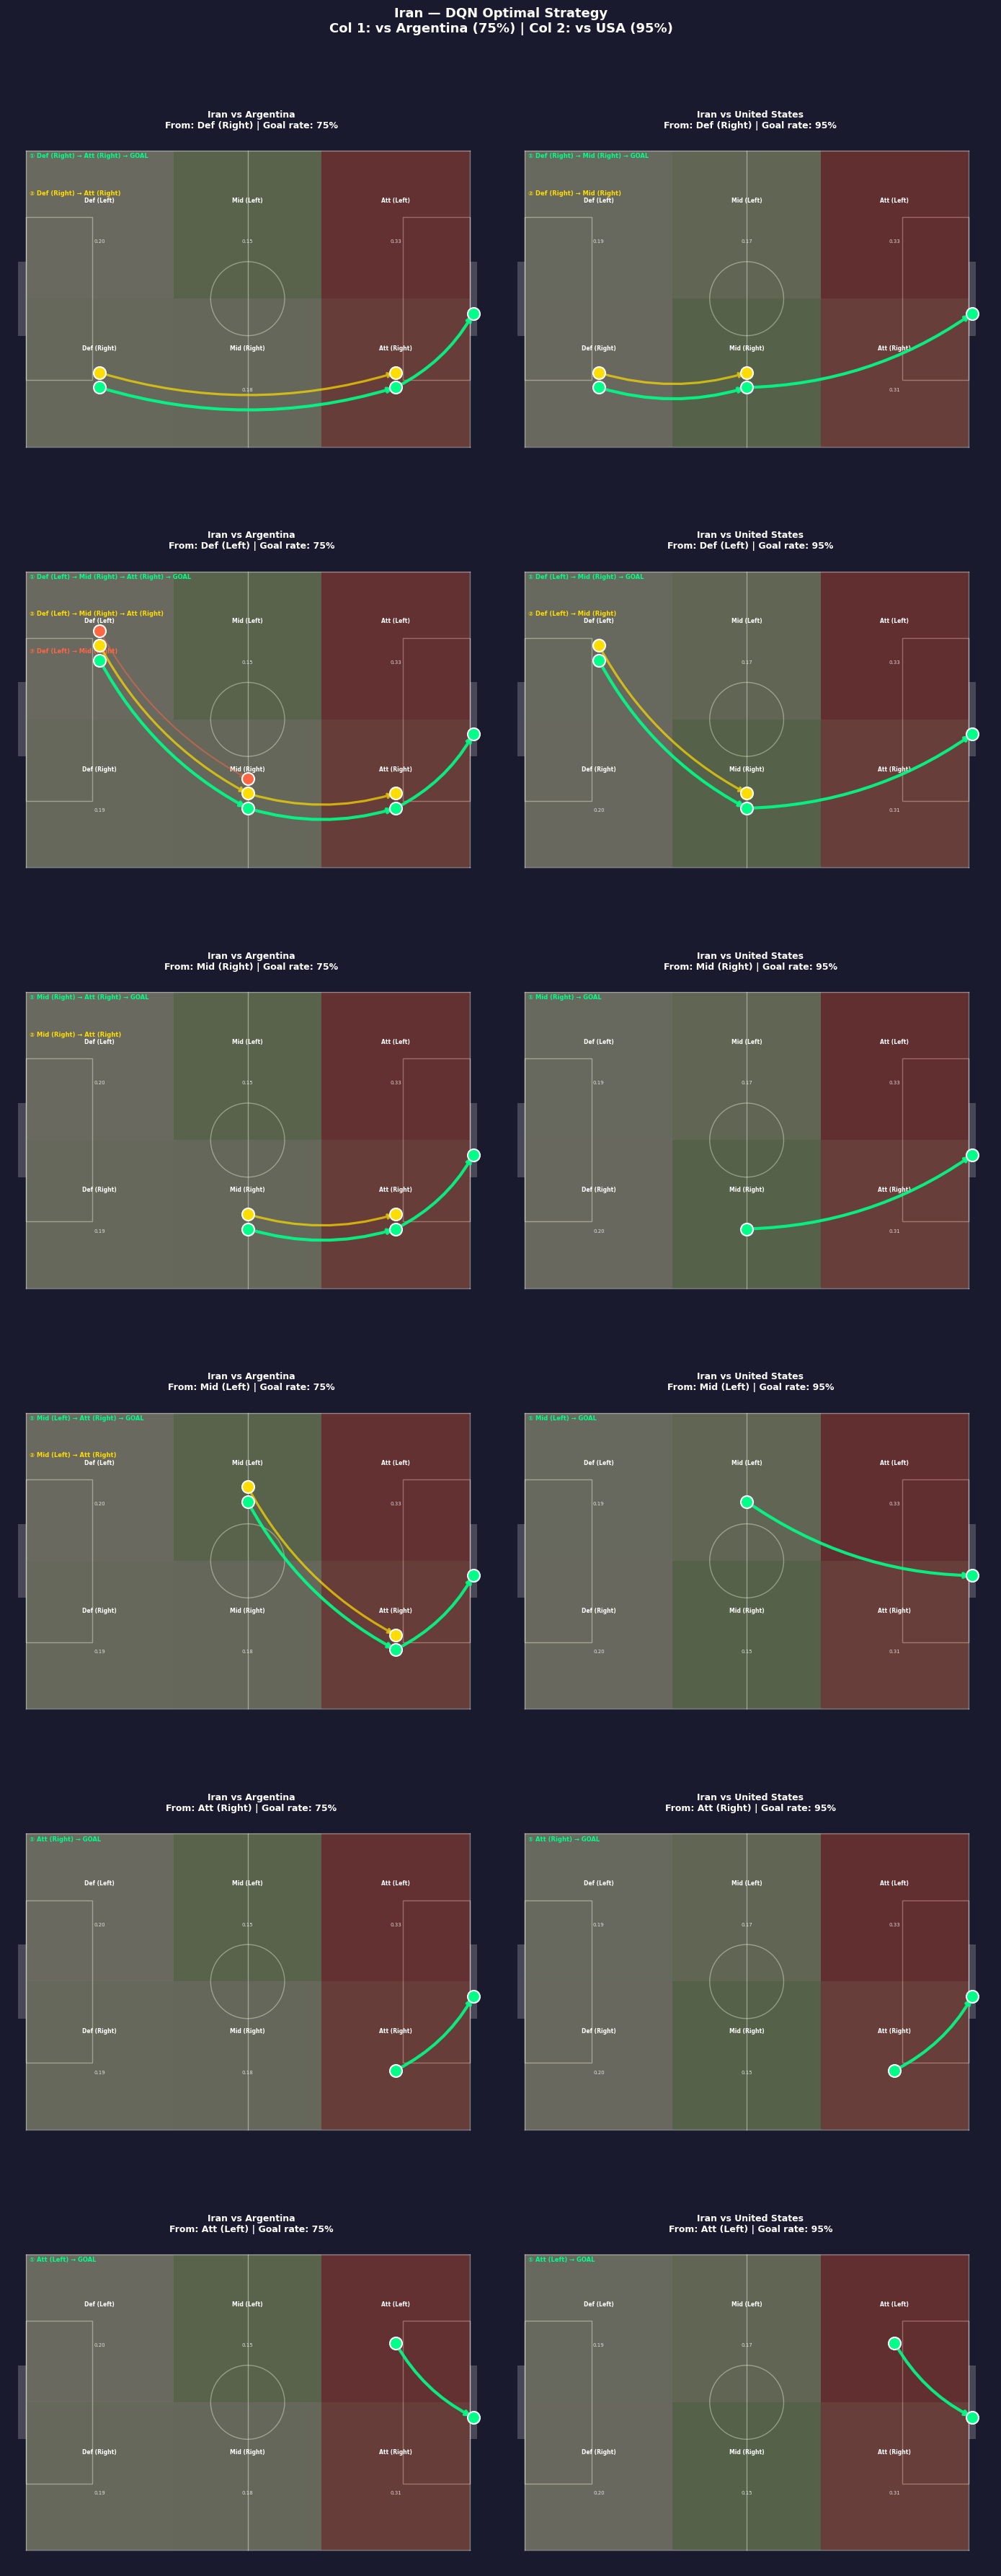


✅ Saved: /content/drive/MyDrive/soccer_rl/rl_policy_all.png
✅ Saved: /content/drive/MyDrive/soccer_rl/iran_rl_vs_arg_usa.png
✅ Block 4 complete


In [8]:
# Block 4: Visualize learned RL policy per opponent
# Shows optimal paths the DQN agent takes from each starting zone
# Compares difficulty (goal rate) across opponents

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

DRIVE_PATH  = '/content/drive/MyDrive/soccer_rl'
ZONE_CENTERS = {
    0: (20,20), 1: (20,60),
    2: (60,20), 3: (60,60),
    4: (100,20), 5: (100,60),
    6: (121,40)
}
ZONES = {
    0: 'Def (Right)', 1: 'Def (Left)',
    2: 'Mid (Right)', 3: 'Mid (Left)',
    4: 'Att (Right)', 5: 'Att (Left)',
    6: 'GOAL'
}

FINAL_GOAL_RATES = {
    'Argentina'    : 0.750,
    'France'       : 0.870,
    'Brazil'       : 0.785,
    'England'      : 0.830,
    'United States': 0.950,
    'Morocco'      : 0.850,
}

# ── 1. Extract greedy policy paths ───────────────────────────
def get_greedy_path(agent, opponent, start_zone, max_steps=8, n_trials=50):
    """Run agent greedily (no exploration) and return most common path."""
    env = SoccerEnv(opponent, defense_profiles, max_steps=max_steps)

    all_paths = []
    for _ in range(n_trials):
        state = env.reset(start_zone=start_zone)
        path  = [start_zone]
        for _ in range(max_steps):
            # Greedy — no random exploration
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_vals  = agent.q_net(state_t)[0]
                mask    = torch.full((7,), float('-inf')).to(device)
                for a in env.valid_actions():
                    mask[a] = q_vals[a]
                action = int(mask.argmax().item())

            state, _, done = env.step(action)
            path.append(action)
            if done:
                break
        all_paths.append(tuple(path))

    # Return most common path
    from collections import Counter
    most_common = Counter(all_paths).most_common(3)
    return [list(p) for p, _ in most_common]

# ── 2. Pitch drawing ──────────────────────────────────────────
def draw_pitch(ax, bg='#2d5a1b'):
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.plot([0,120],[0,0],'w',alpha=0.4,lw=1)
    ax.plot([0,120],[80,80],'w',alpha=0.4,lw=1)
    ax.plot([0,0],[0,80],'w',alpha=0.4,lw=1)
    ax.plot([120,120],[0,80],'w',alpha=0.4,lw=1)
    ax.plot([60,60],[0,80],'w',alpha=0.4,lw=1)
    circle = plt.Circle((60,40),10,color='white',fill=False,alpha=0.4,lw=1)
    ax.add_patch(circle)
    ax.add_patch(patches.Rectangle((0,18),18,44,fill=False,
                 edgecolor='white',alpha=0.4,lw=1))
    ax.add_patch(patches.Rectangle((102,18),18,44,fill=False,
                 edgecolor='white',alpha=0.4,lw=1))
    ax.add_patch(patches.Rectangle((-2,30),2,20,fill=True,
                 facecolor='white',alpha=0.2))
    ax.add_patch(patches.Rectangle((120,30),2,20,fill=True,
                 facecolor='white',alpha=0.2))
    ax.set_xlim(-5,127); ax.set_ylim(-5,85)
    ax.set_aspect('equal'); ax.axis('off')

def draw_zones_pressure(ax, defense_dict):
    zone_rects = {
        0:(0,0,40,40),   1:(0,40,40,40),
        2:(40,0,40,40),  3:(40,40,40,40),
        4:(80,0,40,40),  5:(80,40,40,40),
    }
    for z, (x,y,w,h) in zone_rects.items():
        pressure = defense_dict.get(z, 0.2)
        color    = plt.cm.RdYlGn(1 - pressure * 2.5)
        ax.add_patch(patches.Rectangle((x,y),w,h,
                     facecolor=color,alpha=0.35,zorder=1))
        cx,cy = ZONE_CENTERS[z]
        ax.text(cx, cy+6, ZONES[z],
                ha='center',fontsize=5.5,color='white',fontweight='bold')
        ax.text(cx, cy-5, f'{pressure:.2f}',
                ha='center',fontsize=5,color='white',alpha=0.8)

def draw_path(ax, path, color, lw=3, alpha=0.9, offset=0):
    for i in range(len(path)-1):
        x0,y0 = ZONE_CENTERS[path[i]]
        x1,y1 = ZONE_CENTERS[path[i+1]]
        y0+=offset; y1+=offset
        ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle='->',color=color,
                                   lw=lw,alpha=alpha,
                                   connectionstyle='arc3,rad=0.15'),
                    zorder=5)
    for z in path:
        cx,cy = ZONE_CENTERS[z]
        cy+=offset
        ax.scatter(cx,cy,s=150,color=color,zorder=6,
                   edgecolors='white',linewidths=1.5)

PATH_COLORS = ['#00ff88','#ffdd00','#ff6644']
START_ZONES = list(range(6))

# ── 3. Main visualization — 6 rows x 6 cols ──────────────────
# Rows = starting zones, Cols = opponents
OPPONENTS = list(trained_agents.keys())

fig, axes = plt.subplots(6, 6, figsize=(36, 36))

for row, start in enumerate(START_ZONES):
    for col, opponent in enumerate(OPPONENTS):
        ax     = axes[row, col]
        agent  = trained_agents[opponent]
        defense = defense_profiles.get(opponent, {})

        draw_pitch(ax)
        draw_zones_pressure(ax, defense)

        paths   = get_greedy_path(agent, opponent, start_zone=start)
        offsets = [-4, 0, 4]

        for rank, path in enumerate(paths[:3]):
            draw_path(ax, path, color=PATH_COLORS[rank],
                      lw=3-rank*0.7, alpha=0.9-rank*0.2,
                      offset=offsets[rank])
            zone_names = ' → '.join([ZONES[z] for z in path])
            ax.text(1, 78-rank*10, f'{"①②③"[rank]} {zone_names}',
                    fontsize=4.5, color=PATH_COLORS[rank], fontweight='bold')

        goal_rate = FINAL_GOAL_RATES.get(opponent, 0)
        ax.set_title(f'vs {opponent}\nFrom: {ZONES[start]}\nGoal rate: {goal_rate:.0%}',
                     fontsize=6, fontweight='bold', color='white', pad=3)

plt.suptitle('DQN Learned Policy — Soccer Pass Optimization\n'
             'FIFA World Cup 2022 | Green=Best path | Yellow=2nd | Orange=3rd',
             fontsize=16, fontweight='bold', color='white', y=1.005)
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/rl_policy_all.png', dpi=120,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

# ── 4. Difficulty ranking ─────────────────────────────────────
print("\n── Opponent Difficulty Ranking (DQN) ──")
ranked = sorted(FINAL_GOAL_RATES.items(), key=lambda x: x[1])
for rank, (opponent, rate) in enumerate(ranked, 1):
    bar = '█' * int(rate * 20)
    print(f"   {rank}. {opponent:15s} | {bar:20s} | {rate:.0%} goal rate")

# ── 5. Focused comparison: Iran vs Argentina vs USA ───────────
fig2, axes2 = plt.subplots(6, 2, figsize=(14, 36))

for row, start in enumerate(START_ZONES):
    for col, opponent in enumerate(['Argentina', 'United States']):
        ax     = axes2[row, col]
        agent  = trained_agents[opponent]
        defense = defense_profiles.get(opponent, {})

        draw_pitch(ax)
        draw_zones_pressure(ax, defense)

        paths   = get_greedy_path(agent, opponent, start_zone=start)
        offsets = [-4, 0, 4]

        for rank, path in enumerate(paths[:3]):
            draw_path(ax, path, color=PATH_COLORS[rank],
                      lw=3-rank*0.7, alpha=0.9-rank*0.2,
                      offset=offsets[rank])
            zone_names = ' → '.join([ZONES[z] for z in path])
            ax.text(1, 78-rank*10, f'{"①②③"[rank]} {zone_names}',
                    fontsize=6, color=PATH_COLORS[rank], fontweight='bold')

        goal_rate = FINAL_GOAL_RATES.get(opponent, 0)
        ax.set_title(f'Iran vs {opponent}\nFrom: {ZONES[start]} | Goal rate: {goal_rate:.0%}',
                     fontsize=9, fontweight='bold', color='white', pad=4)

plt.suptitle('Iran — DQN Optimal Strategy\nCol 1: vs Argentina (75%) | Col 2: vs USA (95%)',
             fontsize=13, fontweight='bold', color='white', y=1.01)
fig2.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/iran_rl_vs_arg_usa.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(f"\n✅ Saved: {DRIVE_PATH}/rl_policy_all.png")
print(f"✅ Saved: {DRIVE_PATH}/iran_rl_vs_arg_usa.png")
print("✅ Block 4 complete")